# Telecom Customer Churn Analysis
## Data Profiling and Cleaning

This notebook documents the initial data profiling and cleaning process for the Iranian telecom customer churn dataset.

### Objectives
- Load and inspect the raw dataset
- Assess data structure and data types
- Identify missing values and duplicate records
- Validate categorical and numerical variables
- Standardize column names
- Document data-quality decisions before exploratory and statistical analysis

In [4]:
import pandas as pd

In [5]:
df = pd.read_csv("../data/raw/Customer Churn.csv")

In [6]:
df.shape

(3150, 14)

### Dataset Dimensions

The raw dataset contains **3,150 observations and 14 variables**.

In [7]:
df.head()

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
0,8,0,38,0,4370,71,5,17,3,1,1,30,197.640,0
1,0,0,39,0,318,5,7,4,2,1,2,25,46.035,0
2,10,0,37,0,2453,60,359,24,3,1,1,30,1536.520,0
3,10,0,38,0,4198,66,1,35,1,1,1,15,240.020,0
4,3,0,38,0,2393,58,2,33,1,1,1,15,145.805,0


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Call  Failure            3150 non-null   int64  
 1   Complains                3150 non-null   int64  
 2   Subscription  Length     3150 non-null   int64  
 3   Charge  Amount           3150 non-null   int64  
 4   Seconds of Use           3150 non-null   int64  
 5   Frequency of use         3150 non-null   int64  
 6   Frequency of SMS         3150 non-null   int64  
 7   Distinct Called Numbers  3150 non-null   int64  
 8   Age Group                3150 non-null   int64  
 9   Tariff Plan              3150 non-null   int64  
 10  Status                   3150 non-null   int64  
 11  Age                      3150 non-null   int64  
 12  Customer Value           3150 non-null   float64
 13  Churn                    3150 non-null   int64  
dtypes: float64(1), int64(13)
memory usa

## Data Quality Assessment

Before conducting exploratory or statistical analysis, the dataset is assessed for missing values, duplicate records, data-type issues, and potentially invalid values.

In [9]:
df.isnull().sum()

Call  Failure              0
Complains                  0
Subscription  Length       0
Charge  Amount             0
Seconds of Use             0
Frequency of use           0
Frequency of SMS           0
Distinct Called Numbers    0
Age Group                  0
Tariff Plan                0
Status                     0
Age                        0
Customer Value             0
Churn                      0
dtype: int64

### Missing Values

No standard null values were detected across the 14 variables. However, this does not rule out values that may be invalid or represent missing information using non-null codes.

In [10]:
duplicate_count = df.duplicated().sum()
duplicate_count

np.int64(300)

In [11]:
duplicate_percentage = duplicate_count / len(df) * 100
duplicate_percentage

np.float64(9.523809523809524)

### Duplicate Records

The dataset contains **300 exact repeated records**, representing approximately **9.52% of all rows**.

Further inspection showed that 465 rows participate in 165 repeated record patterns. However, the dataset does not contain a unique customer identifier. Therefore, identical combinations of the available attributes cannot conclusively be classified as accidental duplicate customer records.

**Decision:** Retain these records at this stage rather than removing them without sufficient evidence.

In [12]:
duplicate_counts = (
    df.groupby(list(df.columns))
      .size()
      .reset_index(name="count")
)

duplicate_groups = duplicate_counts[duplicate_counts["count"] > 1]

duplicate_groups["count"].value_counts().sort_index()

count
2     44
3    113
4      4
5      2
6      2
Name: count, dtype: int64

In [13]:
duplicate_groups.shape

(165, 15)

## Variable Validation

The observed values and ranges of key variables are inspected to identify unexpected category codes, impossible values, and potential data-quality issues.

In [14]:
categorical_columns = [
    "Complains",
    "Age Group",
    "Tariff Plan",
    "Status",
    "Churn"
]

for column in categorical_columns:
    values = sorted(df[column].unique())
    print(f"{column}: {[int(value) for value in values]}")

Complains: [0, 1]
Age Group: [1, 2, 3, 4, 5]
Tariff Plan: [1, 2]
Status: [1, 2]
Churn: [0, 1]


In [15]:
[int(value) for value in sorted(df["Charge  Amount"].unique())]

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

## Column Name Standardization

The raw dataset contains inconsistent spacing and capitalization in several column names. To make the analysis easier to read and reduce referencing errors, column names are standardized to lowercase `snake_case`.

The raw CSV remains unchanged; only the in-memory DataFrame is modified.

In [16]:
df.columns = (
    df.columns
      .str.strip()
      .str.replace(r"\s+", "_", regex=True)
      .str.lower()
)

In [17]:
df.columns.tolist()

['call_failure',
 'complains',
 'subscription_length',
 'charge_amount',
 'seconds_of_use',
 'frequency_of_use',
 'frequency_of_sms',
 'distinct_called_numbers',
 'age_group',
 'tariff_plan',
 'status',
 'age',
 'customer_value',
 'churn']

## Numerical Variable Profiling

Summary statistics are reviewed to understand the distributions and ranges of the numerical variables and to identify potentially unusual or implausible values.

In [18]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
call_failure,3150.0,7.627937,7.263886,0.0,1.00000,6.00,12.00000,36.00
complains,3150.0,0.076508,0.265851,0.0,0.00000,0.00,0.00000,1.00
subscription_length,3150.0,32.541905,8.573482,3.0,30.00000,35.00,38.00000,47.00
charge_amount,3150.0,0.942857,1.521072,0.0,0.00000,0.00,1.00000,10.00
seconds_of_use,3150.0,4472.459683,4197.908687,0.0,1391.25000,2990.00,6478.25000,17090.00
frequency_of_use,3150.0,69.460635,57.413308,0.0,27.00000,54.00,95.00000,255.00
frequency_of_sms,3150.0,73.174921,112.237560,0.0,6.00000,21.00,87.00000,522.00
distinct_called_numbers,3150.0,23.509841,17.217337,0.0,10.00000,21.00,34.00000,97.00
age_group,3150.0,2.826032,0.892555,1.0,2.00000,3.00,3.00000,5.00
tariff_plan,3150.0,1.077778,0.267864,1.0,1.00000,1.00,1.00000,2.00


In [19]:
binary_columns = [
    "complains",
    "churn"
]

categorical_columns = [
    "tariff_plan",
    "status"
]

ordinal_columns = [
    "age_group",
    "charge_amount"
]

numerical_columns = [
    "call_failure",
    "subscription_length",
    "seconds_of_use",
    "frequency_of_use",
    "frequency_of_sms",
    "distinct_called_numbers",
    "age",
    "customer_value"
]

In [20]:
numerical_columns

['call_failure',
 'subscription_length',
 'seconds_of_use',
 'frequency_of_use',
 'frequency_of_sms',
 'distinct_called_numbers',
 'age',
 'customer_value']

In [21]:
df[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
call_failure,3150.0,7.627937,7.263886,0.0,1.00000,6.00,12.00000,36.00
subscription_length,3150.0,32.541905,8.573482,3.0,30.00000,35.00,38.00000,47.00
seconds_of_use,3150.0,4472.459683,4197.908687,0.0,1391.25000,2990.00,6478.25000,17090.00
frequency_of_use,3150.0,69.460635,57.413308,0.0,27.00000,54.00,95.00000,255.00
frequency_of_sms,3150.0,73.174921,112.237560,0.0,6.00000,21.00,87.00000,522.00
distinct_called_numbers,3150.0,23.509841,17.217337,0.0,10.00000,21.00,34.00000,97.00
age,3150.0,30.998413,8.831095,15.0,25.00000,30.00,30.00000,55.00
customer_value,3150.0,470.972916,517.015433,0.0,113.80125,228.48,788.38875,2165.28


### Numerical Profiling Findings

The numerical variables show plausible ranges, with no immediately obvious impossible or negative values.

Several usage-related variables, including `seconds_of_use`, `frequency_of_sms`, and `customer_value`, appear potentially right-skewed because their means are substantially higher than their medians and their maximum values are considerably above the upper quartiles.

These observations are not treated as data errors at this stage. Distribution shape and potential outliers will be examined visually during exploratory data analysis before any treatment decisions are made.

In [22]:
df.groupby("age_group")["age"].agg(["min", "max", "count"])

,min,max,count
age_group,,,
1,15,15,123
2,25,25,1037
3,30,30,1425
4,45,45,395
5,55,55,170


In [23]:
pd.crosstab(df["age_group"], df["age"])


age,15,25,30,45,55
age_group,,,,,
1,123,0,0,0,0
2,0,1037,0,0,0
3,0,0,1425,0,0
4,0,0,0,395,0
5,0,0,0,0,170


### Age Variable Validation

The official UCI documentation defines `age_group` as an ordinal variable ranging from 1 (younger age) to 5 (older age). Specific age-range boundaries are not provided.

The dataset also contains an `age` variable with values 15, 25, 30, 45, and 55. Cross-tabulation shows a perfect one-to-one mapping between `age_group` and `age`, indicating that the two variables contain redundant information.

Because `age_group` is explicitly documented by the source while the precise interpretation of `age` is not provided, `age_group` will be retained as the primary age-related feature for subsequent analysis. `age` will not be treated as an independent explanatory variable.

### Source Documentation Discrepancy

The official UCI documentation describes `charge_amount` as an ordinal attribute ranging from 0 (lowest amount) to 9 (highest amount). However, the supplied CSV contains observed values from 0 through 10.

Because there is insufficient evidence to determine whether values of 10 are erroneous, they will be retained. This discrepancy is documented as a data limitation rather than corrected without supporting evidence.

In [24]:
numerical_columns = [
    "call_failure",
    "subscription_length",
    "seconds_of_use",
    "frequency_of_use",
    "frequency_of_sms",
    "distinct_called_numbers",
    "customer_value"
]

# Exploratory Data Analysis

The exploratory analysis investigates the characteristics associated with customer churn. The analysis begins with the overall churn rate before examining differences across customer characteristics, service attributes, and usage behaviour.

The objective at this stage is to identify patterns and potential churn drivers. Statistical significance will be assessed separately during the statistical analysis stage.

In [25]:
churn_counts = df["churn"].value_counts().sort_index()
churn_counts


churn
0    2655
1     495
Name: count, dtype: int64

In [26]:
churn_rates = df["churn"].value_counts(normalize=True).sort_index() * 100
churn_rates.round(2)

churn
0    84.29
1    15.71
Name: proportion, dtype: float64

In [27]:
import matplotlib.pyplot as plt

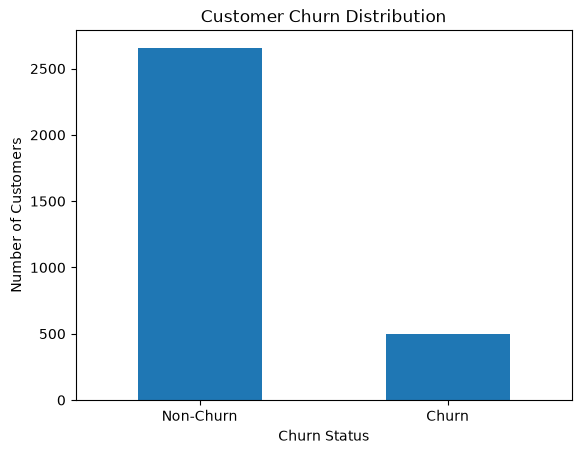

In [28]:
churn_counts.plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")
plt.xticks([0, 1], ["Non-Churn", "Churn"], rotation=0)

plt.show()

## Churn Driver Analysis

The analysis now compares churn rates across customer characteristics and service behaviours to identify potential churn drivers.

### Complaints and Churn

Customer complaints are examined first to determine whether customers who have complained exhibit a higher churn rate than customers who have not complained.

In [29]:
complaint_churn = pd.crosstab(
    df["complains"],
    df["churn"]
)

complaint_churn

churn,0,1
complains,,
0,2614,295
1,41,200


In [30]:
complaint_churn_rate = (
    df.groupby("complains")["churn"]
      .mean()
      .mul(100)
      .round(2)
)

complaint_churn_rate

complains
0    10.14
1    82.99
Name: churn, dtype: float64

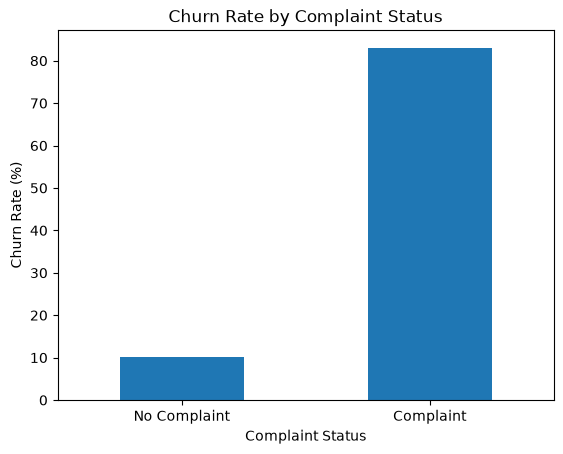

In [31]:
complaint_churn_rate.plot(kind="bar")

plt.title("Churn Rate by Complaint Status")
plt.xlabel("Complaint Status")
plt.ylabel("Churn Rate (%)")
plt.xticks([0, 1], ["No Complaint", "Complaint"], rotation=0)

plt.show()

### Complaints and Churn — Findings

Customers who did not complain had a churn rate of approximately **10.14%**, compared with **82.99%** among customers who complained.

This represents a substantial difference in churn rates and suggests a strong association between customer complaints and churn.

At this exploratory stage, the result is interpreted as an **association rather than evidence of causation**. Statistical testing will later be used to assess whether the observed relationship is statistically significant.

### Subscription Length and Churn

Subscription length is examined to determine whether customers who churn differ in their length of relationship with the telecom provider compared with customers who remain.

In [32]:
df.groupby("churn")["subscription_length"].describe()

,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
0,2655.0,32.662524,8.392357,3.0,29.0,35.0,38.0,47.0
1,495.0,31.894949,9.469163,3.0,31.0,35.0,37.0,45.0


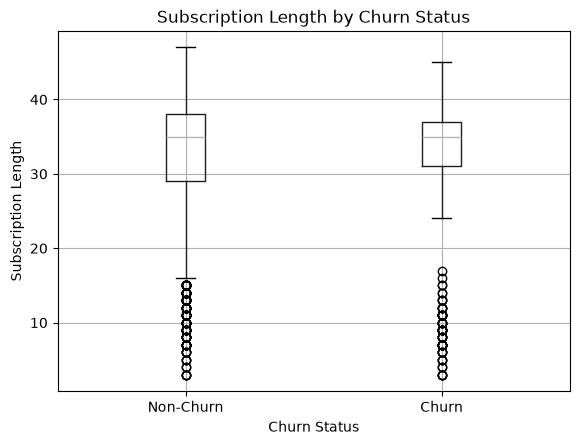

In [33]:
df.boxplot(
    column="subscription_length",
    by="churn"
)

plt.title("Subscription Length by Churn Status")
plt.suptitle("")
plt.xlabel("Churn Status")
plt.ylabel("Subscription Length")
plt.xticks([1, 2], ["Non-Churn", "Churn"])

plt.show()

### Subscription Length — Findings

Churned and non-churned customers exhibit broadly similar subscription-length distributions.

The mean subscription length is slightly lower among churned customers (31.89) than among non-churned customers (32.66), while both groups have the same median subscription length of 35.

The substantial overlap between the box plots suggests that subscription length alone does not show a strong overall separation between churned and non-churned customers.

Several low subscription-length observations are identified as potential outliers by the box plot. These observations are retained because there is no evidence that they represent data errors.

### Seconds of Use and Churn

Customer usage is examined to determine whether churned customers exhibit different levels of service usage compared with customers who remain.

In [34]:
df.groupby("churn")["seconds_of_use"].describe()

,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
0,2655.0,5014.224105,4312.742630,0.0,1819.0,3530.0,6892.5,17090.0
1,495.0,1566.632323,1539.203365,0.0,318.0,1182.0,2391.5,6123.0


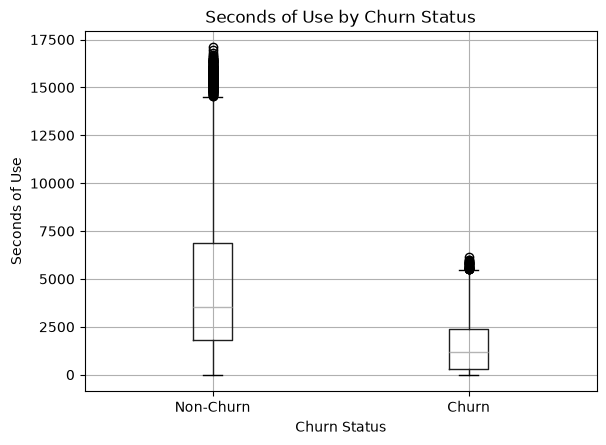

In [35]:
df.boxplot(
    column="seconds_of_use",
    by="churn"
)

plt.title("Seconds of Use by Churn Status")
plt.suptitle("")
plt.xlabel("Churn Status")
plt.ylabel("Seconds of Use")
plt.xticks([1, 2], ["Non-Churn", "Churn"])

plt.show()

### Seconds of Use — Findings

Churned customers exhibit substantially lower service usage than non-churned customers.

The mean seconds of use is approximately **1,567 for churned customers**, compared with **5,014 for non-churned customers**. The median shows a similar pattern, at approximately **1,182 for churned customers** versus **3,530 for non-churned customers**.

Although the distributions overlap, the box plot shows that the central distribution for churned customers is concentrated at substantially lower usage levels.

This provides descriptive evidence of a strong association between **lower service usage and customer churn**. Statistical testing will later determine whether the observed difference is statistically significant.

### Frequency of Use and Churn

Frequency of use is examined to determine whether customers who churn interact with the telecom service less frequently than customers who remain.

In [36]:
df.groupby("churn")["frequency_of_use"].describe()

,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
0,2655.0,76.979284,58.499847,0.0,32.0,63.0,104.0,255.0
1,495.0,29.133333,26.323478,0.0,6.0,25.0,45.5,100.0


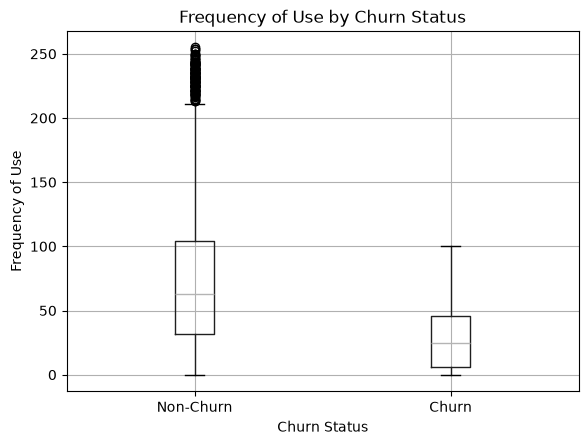

In [37]:
df.boxplot(
    column="frequency_of_use",
    by="churn"
)

plt.title("Frequency of Use by Churn Status")
plt.suptitle("")
plt.xlabel("Churn Status")
plt.ylabel("Frequency of Use")
plt.xticks([1, 2], ["Non-Churn", "Churn"])

plt.show()

In [38]:
df[["seconds_of_use", "frequency_of_use"]].corr()

,seconds_of_use,frequency_of_use
seconds_of_use,1.000000,0.946489
frequency_of_use,0.946489,1.000000


### Frequency of Use — Findings

Churned customers exhibit substantially lower usage frequency than non-churned customers. The mean frequency of use is approximately **29.13 among churned customers**, compared with **76.98 among non-churned customers**. Median usage frequency shows a similar difference, at **25 for churned customers** versus **63 for non-churned customers**.

This provides descriptive evidence of a strong association between lower usage frequency and churn.

However, `frequency_of_use` is also very strongly positively correlated with `seconds_of_use` (**r ≈ 0.95**). Therefore, these variables should not automatically be interpreted as independent churn drivers. Instead, they may represent related dimensions of an underlying **customer engagement** pattern.

This relationship will be considered during subsequent statistical and predictive analysis.

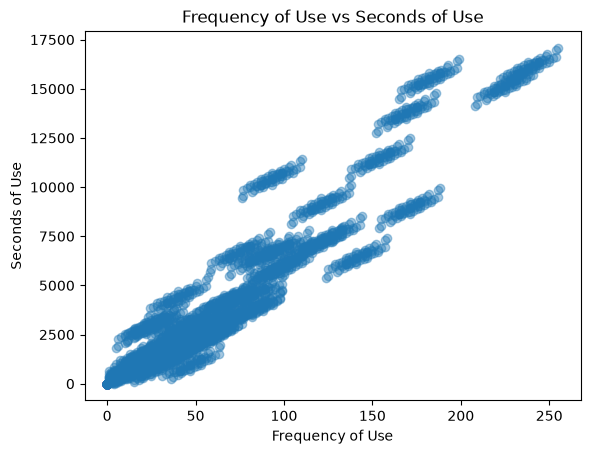

In [39]:
plt.scatter(
    df["frequency_of_use"],
    df["seconds_of_use"],
    alpha=0.4
)

plt.title("Frequency of Use vs Seconds of Use")
plt.xlabel("Frequency of Use")
plt.ylabel("Seconds of Use")

plt.show()

### Usage Variable Relationship

The scatter plot confirms a strong positive relationship between `frequency_of_use` and `seconds_of_use`. Customers with higher usage frequency generally accumulate more total seconds of use, consistent with the high correlation coefficient (**r ≈ 0.95**).

The relationship is strong but not perfectly linear, and several distinct usage patterns are visible in the data.

Because both variables are strongly related and both show substantially lower values among churned customers, they may represent overlapping dimensions of **customer engagement** rather than completely independent churn drivers.

### Frequency of SMS and Churn

SMS usage is examined to determine whether messaging activity differs between churned and non-churned customers.

In [40]:
df.groupby("churn")["frequency_of_sms"].describe()

,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
0,2655.0,83.871563,118.808594,0.0,7.0,25.0,133.0,522.0
1,495.0,15.802020,23.515289,0.0,0.0,9.0,23.0,204.0


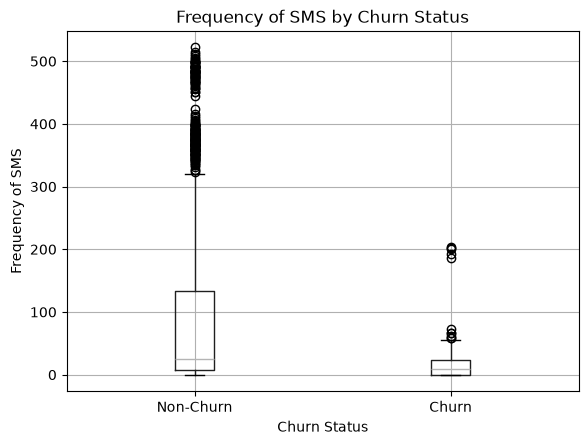

In [41]:
df.boxplot(
    column="frequency_of_sms",
    by="churn"
)

plt.title("Frequency of SMS by Churn Status")
plt.suptitle("")
plt.xlabel("Churn Status")
plt.ylabel("Frequency of SMS")
plt.xticks([1, 2], ["Non-Churn", "Churn"])

plt.show()

### Frequency of SMS — Findings

Churned customers exhibit substantially lower SMS usage than non-churned customers. The mean frequency of SMS is approximately **15.80 among churned customers**, compared with **83.87 among non-churned customers**. Median SMS frequency also differs, at **9 for churned customers** versus **25 for non-churned customers**.

The substantial difference between the mean and median, particularly among non-churned customers, indicates a strongly right-skewed distribution. The box plot also identifies several high-SMS-usage observations as potential outliers.

Despite some overlap between the groups, the central distribution of SMS usage is lower among churned customers. This provides descriptive evidence of a strong association between **lower SMS usage frequency and customer churn**.

These observations will later be evaluated using formal statistical testing.

In [42]:
usage_correlation = df[
    [
        "seconds_of_use",
        "frequency_of_use",
        "frequency_of_sms"
    ]
].corr()

usage_correlation

,seconds_of_use,frequency_of_use,frequency_of_sms
seconds_of_use,1.000000,0.946489,0.102123
frequency_of_use,0.946489,1.000000,0.100019
frequency_of_sms,0.102123,0.100019,1.000000


### Usage Correlation Findings

`seconds_of_use` and `frequency_of_use` are very strongly positively correlated (**r ≈ 0.95**), indicating that these variables capture closely related aspects of general service usage.

In contrast, `frequency_of_sms` has only weak positive correlations with both `seconds_of_use` (**r ≈ 0.10**) and `frequency_of_use` (**r ≈ 0.10**).

Although all three variables show lower values among churned customers, SMS activity therefore appears to represent a relatively distinct dimension of customer behaviour rather than simply duplicating the general usage measures.

This distinction will be considered in subsequent statistical and predictive analysis.

### Customer Value and Churn

Customer value is examined to determine whether customers who churn differ in their estimated value to the telecom provider compared with customers who remain.

In [43]:
df.groupby("churn")["customer_value"].describe()

,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
0,2655.0,535.511501,536.214629,0.0,142.065,268.07,864.5475,2165.280
1,495.0,124.811414,129.429850,0.0,38.375,96.84,181.3225,987.255


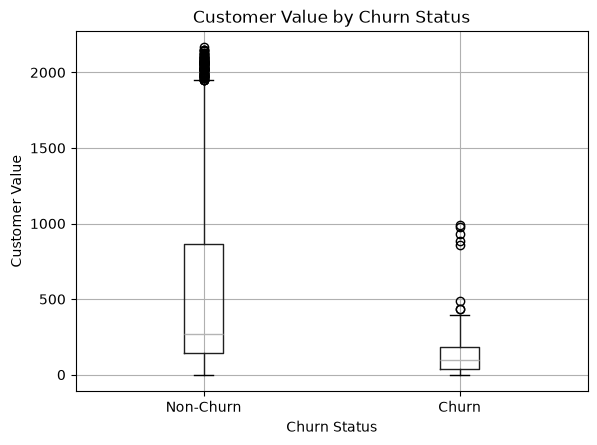

In [44]:
df.boxplot(
    column="customer_value",
    by="churn"
)

plt.title("Customer Value by Churn Status")
plt.suptitle("")
plt.xlabel("Churn Status")
plt.ylabel("Customer Value")
plt.xticks([1, 2], ["Non-Churn", "Churn"])

plt.show()

In [45]:
customer_value_summary = df.groupby("churn")["customer_value"].agg(
    customer_count="count",
    total_customer_value="sum",
    average_customer_value="mean",
    median_customer_value="median"
)

customer_value_summary

,customer_count,total_customer_value,average_customer_value,median_customer_value
churn,,,,
0,2655,1421783.035,535.511501,268.07
1,495,61781.650,124.811414,96.84


In [46]:
customer_value_share = (
    df.groupby("churn")["customer_value"].sum()
    / df["customer_value"].sum()
    * 100
)

customer_value_share.round(2)

churn
0    95.84
1     4.16
Name: customer_value, dtype: float64

### Customer Value — Business Findings

Churned customers have substantially lower customer values than non-churned customers. Average customer value is approximately **124.81 among churned customers**, compared with **535.51 among non-churned customers**, while median values are **96.84** and **268.07**, respectively.

Although churned customers represent approximately **15.71% of all customers**, they account for only **4.16% of total customer value** in the dataset. This indicates that churn is disproportionately concentrated among relatively lower-value customers.

This may reduce the immediate commercial exposure associated with the observed churn compared with a scenario in which high-value customers were leaving at similar rates. However, churn should not be considered commercially unimportant, since customer acquisition costs, future customer value, and the presence of some relatively high-value churners may still justify retention interventions.

From a business perspective, retention strategies may therefore benefit from considering both **churn risk and customer value**, allowing higher-value customers at elevated churn risk to receive greater retention priority.

### Distinct Called Numbers and Churn

The number of distinct called numbers is examined to determine whether the breadth of customer calling activity differs between churned and non-churned customers.

In [47]:
df.groupby("churn")["distinct_called_numbers"].describe()

,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
0,2655.0,25.582674,17.389349,0.0,12.0,23.0,36.0,97.0
1,495.0,12.391919,10.867622,0.0,2.0,10.0,20.0,48.0


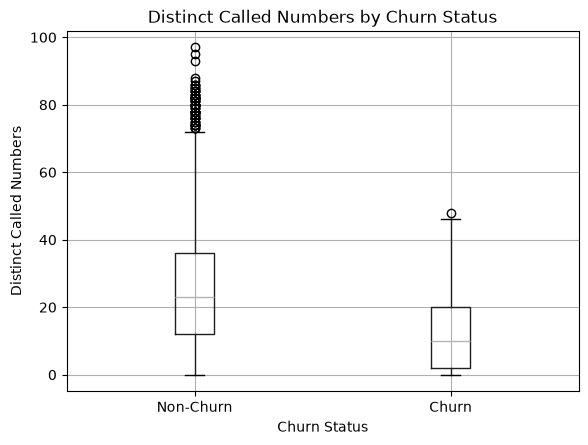

In [48]:
df.boxplot(
    column="distinct_called_numbers",
    by="churn"
)

plt.title("Distinct Called Numbers by Churn Status")
plt.suptitle("")
plt.xlabel("Churn Status")
plt.ylabel("Distinct Called Numbers")
plt.xticks([1, 2], ["Non-Churn", "Churn"])

plt.show()

In [49]:
df[
    [
        "seconds_of_use",
        "frequency_of_use",
        "frequency_of_sms",
        "distinct_called_numbers"
    ]
].corr()

,seconds_of_use,frequency_of_use,frequency_of_sms,distinct_called_numbers
seconds_of_use,1.000000,0.946489,0.102123,0.676536
frequency_of_use,0.946489,1.000000,0.100019,0.736114
frequency_of_sms,0.102123,0.100019,1.000000,0.079650
distinct_called_numbers,0.676536,0.736114,0.079650,1.000000


### Distinct Called Numbers — Findings

Non-churned customers interact with substantially more distinct called numbers than churned customers. The mean number of distinct called numbers is approximately **25.58 for non-churned customers** compared with **12.39 for churned customers**, while the corresponding medians are **23** and **10**.

The box plots show partial overlap, but the distribution for non-churned customers is clearly shifted toward higher values. This provides descriptive evidence that customers with a broader calling network tend to exhibit lower churn.

`distinct_called_numbers` is strongly positively correlated with `frequency_of_use` (**r ≈ 0.74**) and also positively correlated with `seconds_of_use` (**r ≈ 0.68**). In contrast, its relationship with `frequency_of_sms` is weak (**r ≈ 0.08**).

These findings suggest that the number of distinct called numbers may represent another aspect of general service engagement, while SMS behaviour remains relatively distinct.

### Tariff Plan and Churn

Churn rates are compared across tariff plans to determine whether customer churn differs between the two available plan categories.

In [50]:
tariff_churn = pd.crosstab(
    df["tariff_plan"],
    df["churn"]
)

tariff_churn

churn,0,1
tariff_plan,,
1,2416,489
2,239,6


In [51]:
tariff_churn_rate = (
    df.groupby("tariff_plan")["churn"]
      .mean()
      .mul(100)
      .round(2)
)

tariff_churn_rate

tariff_plan
1    16.83
2     2.45
Name: churn, dtype: float64

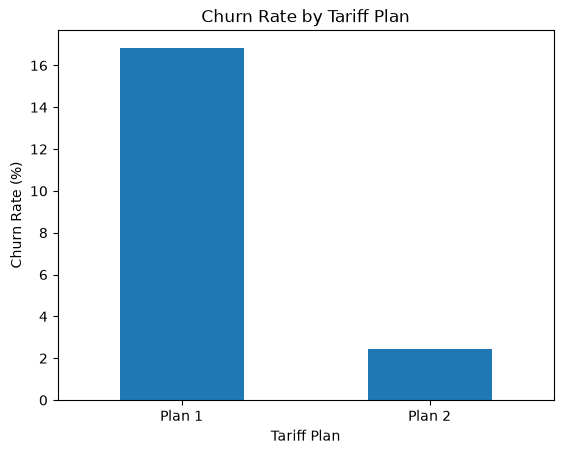

In [52]:
tariff_churn_rate.plot(kind="bar")

plt.title("Churn Rate by Tariff Plan")
plt.xlabel("Tariff Plan")
plt.ylabel("Churn Rate (%)")
plt.xticks([0, 1], ["Plan 1", "Plan 2"], rotation=0)

plt.show()

### Tariff Plan — Findings

Tariff Plan 1 contains 2,905 customers, compared with 245 customers in Tariff Plan 2.

The churn rate for Tariff Plan 1 is approximately **16.83%**, compared with only **2.45%** for Tariff Plan 2. This represents a difference of approximately **14.38 percentage points**, with the churn rate for Plan 1 being approximately **6.9 times** that of Plan 2.

The substantial difference provides descriptive evidence of an association between tariff plan and customer churn. However, the two tariff-plan groups are highly unequal in size, and statistical testing will later be used to determine whether the observed association is statistically significant.

The result may warrant further investigation into differences between the two tariff plans, including their pricing, service features, customer profiles, and other characteristics that could help explain the difference in churn.

### Customer Status and Churn

Churn rates are compared across customer status categories to determine whether churn behaviour differs between Status 1 and Status 2 customers.

In [53]:
status_churn = pd.crosstab(
    df["status"],
    df["churn"]
)

status_churn

churn,0,1
status,,
1,2243,125
2,412,370


In [54]:
status_churn_rate = (
    df.groupby("status")["churn"]
      .mean()
      .mul(100)
      .round(2)
)

status_churn_rate

status
1     5.28
2    47.31
Name: churn, dtype: float64

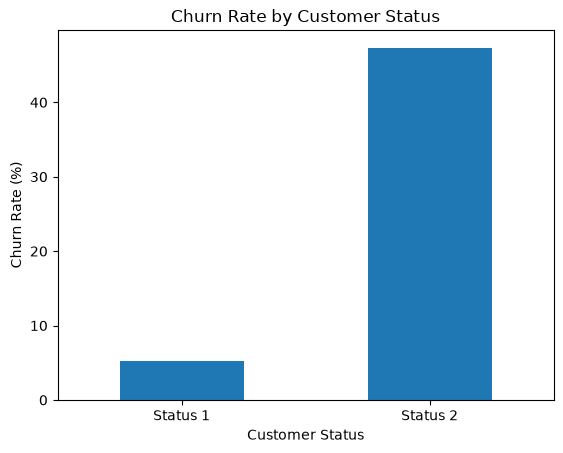

In [55]:
status_churn_rate.plot(kind="bar")

plt.title("Churn Rate by Customer Status")
plt.xlabel("Customer Status")
plt.ylabel("Churn Rate (%)")
plt.xticks([0, 1], ["Status 1", "Status 2"], rotation=0)

plt.show()

### Age Group and Churn

Churn rates are compared across age groups to determine whether customer churn behaviour differs between age categories.


In [56]:
age_churn = pd.crosstab(
    df["age_group"],
    df["churn"]
)

age_churn


churn,0,1
age_group,,
1,123,0
2,853,184
3,1195,230
4,316,79
5,168,2


In [57]:
age_churn

churn,0,1
age_group,,
1,123,0
2,853,184
3,1195,230
4,316,79
5,168,2


In [59]:
age_churn_rate = (
    df.groupby("age_group")["churn"]
      .mean()
      .mul(100)
      .round(2)
)

age_churn_rate

age_group
1     0.00
2    17.74
3    16.14
4    20.00
5     1.18
Name: churn, dtype: float64

In [60]:
age_churn_rate

age_group
1     0.00
2    17.74
3    16.14
4    20.00
5     1.18
Name: churn, dtype: float64

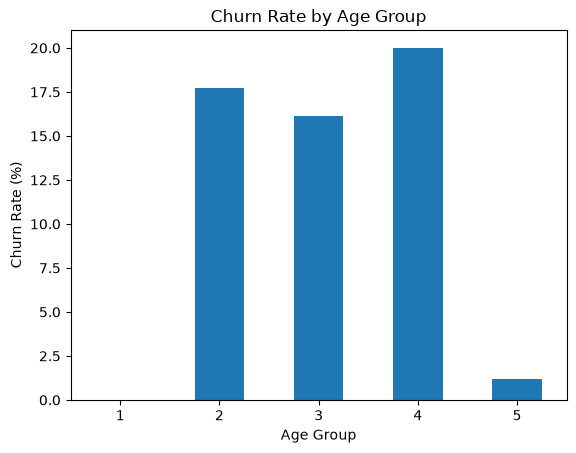

In [61]:
age_churn_rate.plot(kind="bar")

plt.title("Churn Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.show()

### Age Group — Findings

Customer churn varies considerably across age groups and does not follow a simple increasing or decreasing pattern.

Age Group 4 (age 45 in the dataset) has the highest observed churn rate at **20.00%**, followed by Age Group 2 (age 25) at **17.74%** and Age Group 3 (age 30) at **16.14%**.

In contrast, Age Group 1 (age 15) recorded **0.00% churn**, while Age Group 5 (age 55) recorded only **1.18% churn**.

The relationship between age group and churn therefore appears non-linear and irregular, with churn concentrated primarily among the middle age categories represented in the dataset. However, the age groups differ substantially in sample size, particularly Groups 1 and 5, so these descriptive differences should be interpreted cautiously and evaluated through subsequent statistical testing.